# Linear Probe Inference — Notebook Style

This notebook follows the same overall structure as your existing `inference.ipynb`, but uses a **linear probe** on top of a frozen SimCLR / SupCon encoder.

It is designed to:
- load a pretrained encoder checkpoint
- extract frozen features using the same feature handling as your training notebook
- train a linear probe on the train split
- evaluate on the test split
- run single-image sample inference
- run folder-based sample testing

**Feature rule kept consistent with your earlier setup**
- `simclr` → use normalized `h`
- `supcon` → use raw `h`
- `supcon_2stage` → use normalized `h`


## Section 1 — Setup & Config

In [18]:
from pathlib import Path
import random

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, models, transforms


In [19]:
# Global config

SEED = 42
IMG_SIZE = 224
NUM_WORKERS = 0

DEVICE = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)

DATA_ROOT = Path("rust_dataset")
TRAIN_DIR = DATA_ROOT / "train"
TEST_DIR  = DATA_ROOT / "test"

MODEL_CHOICE = "simclr"   # "simclr", "supcon", or "supcon_2stage"

CKPT_MAP = {
    "simclr": "simclr_best.pt",
    "supcon": "supcon_best.pt",
    "supcon_2stage": "supcon_2stage_best.pt",
}

NORMALIZE_MAP = {
    "simclr": True,
    "supcon": False,
    "supcon_2stage": True,
}

LINEAR_PROBE_DIR = Path("saved_linear_probes")
LINEAR_PROBE_DIR.mkdir(parents=True, exist_ok=True)

LINEAR_PROBE_PATH = LINEAR_PROBE_DIR / f"linear_probe_{MODEL_CHOICE}.pt"

PROBE_EPOCHS = 50
PROBE_LR = 1e-3
PROBE_BATCH = 64

SAMPLE_IMAGE_PATH = "testing6.jpg"
SAMPLE_FOLDER_PATH = str(TEST_DIR / "CORROSION")

print("DEVICE           :", DEVICE)
print("MODEL_CHOICE     :", MODEL_CHOICE)
print("TRAIN_DIR exists :", TRAIN_DIR.exists(), TRAIN_DIR)
print("TEST_DIR exists  :", TEST_DIR.exists(), TEST_DIR)
print("CKPT_PATH        :", CKPT_MAP[MODEL_CHOICE])
print("LINEAR_PROBE_PATH:", LINEAR_PROBE_PATH)


DEVICE           : mps
MODEL_CHOICE     : simclr
TRAIN_DIR exists : True rust_dataset/train
TEST_DIR exists  : True rust_dataset/test
CKPT_PATH        : simclr_best.pt
LINEAR_PROBE_PATH: saved_linear_probes/linear_probe_simclr.pt


In [20]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)


## Section 2 — Model Definitions

In [21]:
class SimCLR(nn.Module):
    def __init__(self, proj_dim=128):
        super().__init__()
        base = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        feat_dim = base.fc.in_features
        base.fc = nn.Identity()
        self.encoder = base
        self.projector = nn.Sequential(
            nn.Linear(feat_dim, feat_dim),
            nn.ReLU(inplace=True),
            nn.Linear(feat_dim, proj_dim),
        )

    def forward(self, x):
        h = self.encoder(x)
        z = self.projector(h)
        z = F.normalize(z, dim=1)
        return h, z


class SupConResNet(nn.Module):
    def __init__(self, proj_dim=128, pretrained_backbone=False):
        super().__init__()
        weights = models.ResNet18_Weights.DEFAULT if pretrained_backbone else None
        base = models.resnet18(weights=weights)
        feat_dim = base.fc.in_features
        base.fc = nn.Identity()
        self.encoder = base
        self.projector = nn.Sequential(
            nn.Linear(feat_dim, feat_dim),
            nn.ReLU(inplace=True),
            nn.Linear(feat_dim, proj_dim),
        )

    def forward(self, x):
        h = self.encoder(x)
        z = self.projector(h)
        z = F.normalize(z, dim=1)
        return h, z


In [22]:
def load_model(model_choice, ckpt_path, device=DEVICE):
    ckpt_path = Path(ckpt_path)

    if model_choice == "simclr":
        model = SimCLR(proj_dim=128)
    elif model_choice == "supcon":
        model = SupConResNet(proj_dim=128, pretrained_backbone=False)
    elif model_choice == "supcon_2stage":
        model = SupConResNet(proj_dim=128, pretrained_backbone=True)
    else:
        raise ValueError(f"Unknown model_choice: {model_choice}")

    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)

    if isinstance(ckpt, dict) and "state_dict" in ckpt:
        state = ckpt["state_dict"]
    else:
        state = ckpt

    model.load_state_dict(state, strict=False)
    model.to(device)
    model.eval()
    return model


## Section 3 — Transforms & Feature Utilities

In [23]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


def l2_normalize(x, eps=1e-12):
    return x / (x.norm(dim=1, keepdim=True) + eps)


def extract_features(model, dataloader, normalize_h=False, device=DEVICE):
    all_h = []
    all_y = []

    model.eval()
    with torch.no_grad():
        for xb, yb in dataloader:
            xb = xb.to(device)
            h, _ = model(xb)
            if normalize_h:
                h = l2_normalize(h)
            all_h.append(h.cpu())
            all_y.append(yb.cpu())

    H = torch.cat(all_h, dim=0)
    y = torch.cat(all_y, dim=0)
    return H, y


## Section 4 — Build Datasets and Extract Frozen Features

In [24]:
train_ds = datasets.ImageFolder(TRAIN_DIR, transform=eval_transform)
test_ds  = datasets.ImageFolder(TEST_DIR,  transform=eval_transform)

train_dl = DataLoader(train_ds, batch_size=64, shuffle=False, num_workers=NUM_WORKERS)
test_dl  = DataLoader(test_ds,  batch_size=64, shuffle=False, num_workers=NUM_WORKERS)

class_names = train_ds.classes

print("Classes:", class_names)
print("Train size:", len(train_ds))
print("Test size :", len(test_ds))


Classes: ['CORROSION', 'HARD_NEGATIVE', 'NOCORROSION']
Train size: 2472
Test size : 764


In [25]:
normalize_h = NORMALIZE_MAP[MODEL_CHOICE]
encoder = load_model(MODEL_CHOICE, CKPT_MAP[MODEL_CHOICE], device=DEVICE)

H_train, y_train = extract_features(encoder, train_dl, normalize_h=normalize_h, device=DEVICE)
H_test,  y_test  = extract_features(encoder, test_dl,  normalize_h=normalize_h, device=DEVICE)

print("H_train:", H_train.shape)
print("y_train:", y_train.shape)
print("H_test :", H_test.shape)
print("y_test :", y_test.shape)


H_train: torch.Size([2472, 512])
y_train: torch.Size([2472])
H_test : torch.Size([764, 512])
y_test : torch.Size([764])


## Section 5 — Train the Linear Probe

In [26]:
def train_linear_probe(H_train, y_train, H_test, y_test, num_classes,
                       epochs=50, lr=1e-3, batch_size=64, device=DEVICE):
    probe = nn.Linear(H_train.shape[1], num_classes).to(device)
    optimizer = Adam(probe.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    train_ds = TensorDataset(H_train, y_train)
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

    history = {"loss": [], "test_acc": []}
    best_acc = -1.0
    best_state = None

    for epoch in range(epochs):
        probe.train()
        running_loss = 0.0
        total = 0

        for xb, yb in train_dl:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            logits = probe(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * xb.size(0)
            total += xb.size(0)

        epoch_loss = running_loss / max(total, 1)

        probe.eval()
        with torch.no_grad():
            logits_test = probe(H_test.to(device))
            preds_test = logits_test.argmax(dim=1).cpu()
            test_acc = (preds_test == y_test).float().mean().item() * 100.0

        history["loss"].append(epoch_loss)
        history["test_acc"].append(test_acc)

        if test_acc > best_acc:
            best_acc = test_acc
            best_state = {k: v.detach().cpu().clone() for k, v in probe.state_dict().items()}

        print(f"Epoch {epoch+1:03d}/{epochs} | loss={epoch_loss:.4f} | test_acc={test_acc:.2f}%")

    probe.load_state_dict(best_state)
    return probe, history, best_acc


In [27]:
probe, history, best_acc = train_linear_probe(
    H_train, y_train, H_test, y_test,
    num_classes=len(class_names),
    epochs=PROBE_EPOCHS,
    lr=PROBE_LR,
    batch_size=PROBE_BATCH,
    device=DEVICE
)

print(f"\nBest test accuracy: {best_acc:.2f}%")


Epoch 001/50 | loss=1.0522 | test_acc=64.92%
Epoch 002/50 | loss=0.9618 | test_acc=65.05%
Epoch 003/50 | loss=0.8939 | test_acc=69.63%
Epoch 004/50 | loss=0.8363 | test_acc=79.06%
Epoch 005/50 | loss=0.7857 | test_acc=82.98%
Epoch 006/50 | loss=0.7419 | test_acc=84.82%
Epoch 007/50 | loss=0.7041 | test_acc=86.65%
Epoch 008/50 | loss=0.6706 | test_acc=87.04%
Epoch 009/50 | loss=0.6412 | test_acc=87.57%
Epoch 010/50 | loss=0.6152 | test_acc=87.43%
Epoch 011/50 | loss=0.5920 | test_acc=88.09%
Epoch 012/50 | loss=0.5711 | test_acc=89.01%
Epoch 013/50 | loss=0.5520 | test_acc=89.27%
Epoch 014/50 | loss=0.5348 | test_acc=89.27%
Epoch 015/50 | loss=0.5192 | test_acc=89.79%
Epoch 016/50 | loss=0.5045 | test_acc=89.66%
Epoch 017/50 | loss=0.4912 | test_acc=89.92%
Epoch 018/50 | loss=0.4791 | test_acc=90.45%
Epoch 019/50 | loss=0.4678 | test_acc=90.45%
Epoch 020/50 | loss=0.4572 | test_acc=90.58%
Epoch 021/50 | loss=0.4474 | test_acc=90.58%
Epoch 022/50 | loss=0.4384 | test_acc=90.71%
Epoch 023/

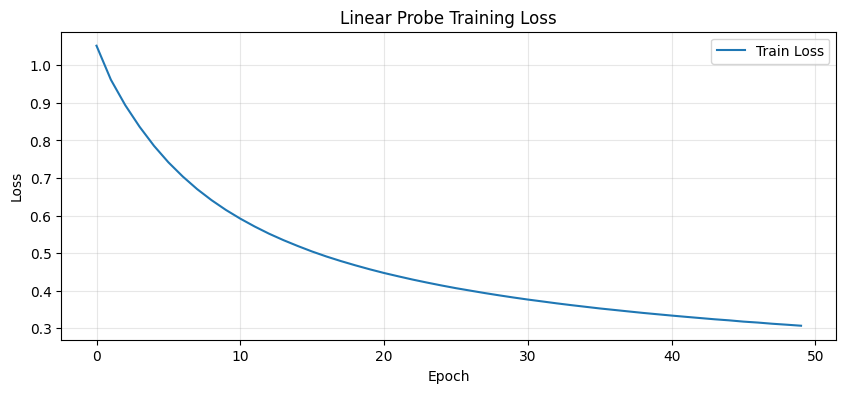

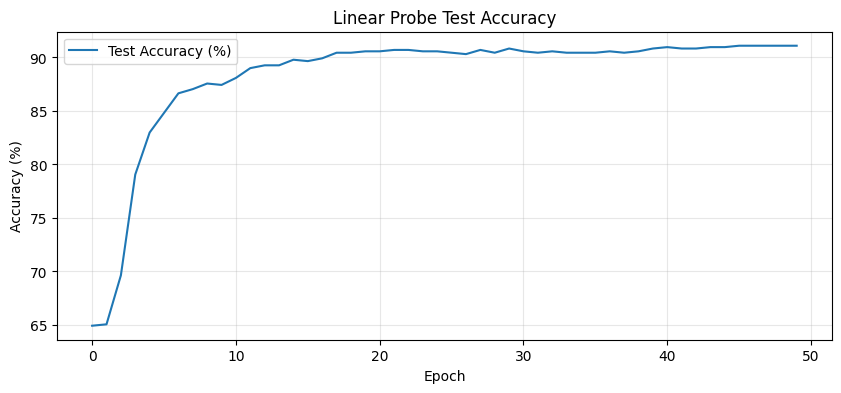

In [28]:
plt.figure(figsize=(10, 4))
plt.plot(history["loss"], label="Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Linear Probe Training Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history["test_acc"], label="Test Accuracy (%)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Linear Probe Test Accuracy")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## Section 6 — Save and Reload the Linear Probe

In [29]:
torch.save(
    {
        "state_dict": probe.state_dict(),
        "input_dim": H_train.shape[1],
        "num_classes": len(class_names),
        "class_names": class_names,
        "model_choice": MODEL_CHOICE,
        "normalize_h": normalize_h,
    },
    LINEAR_PROBE_PATH
)

print("Saved linear probe to:", LINEAR_PROBE_PATH)


Saved linear probe to: saved_linear_probes/linear_probe_simclr.pt


In [30]:
def load_linear_probe(checkpoint_path, device=DEVICE):
    ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
    probe = nn.Linear(ckpt["input_dim"], ckpt["num_classes"]).to(device)
    probe.load_state_dict(ckpt["state_dict"])
    probe.eval()
    return probe, ckpt

probe_loaded, probe_ckpt = load_linear_probe(LINEAR_PROBE_PATH, device=DEVICE)
print("Reloaded classes:", probe_ckpt["class_names"])


Reloaded classes: ['CORROSION', 'HARD_NEGATIVE', 'NOCORROSION']


## Section 7 — Single Image Inference

In [31]:
def extract_single_feature(model, image_path, normalize_h=False, device=DEVICE):
    image_path = Path(image_path)
    image = Image.open(image_path).convert("RGB")
    x = eval_transform(image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        h, _ = model(x)
        if normalize_h:
            h = l2_normalize(h)

    return image, h


def predict_single_image_linear_probe(model_choice, linear_probe_path, image_path, show=True):
    normalize_h = NORMALIZE_MAP[model_choice]
    encoder = load_model(model_choice, CKPT_MAP[model_choice], device=DEVICE)
    probe, ckpt = load_linear_probe(linear_probe_path, device=DEVICE)
    class_names = ckpt["class_names"]

    image, h = extract_single_feature(encoder, image_path, normalize_h=normalize_h, device=DEVICE)

    with torch.no_grad():
        logits = probe(h)
        probs = torch.softmax(logits, dim=1).squeeze(0).cpu()
        pred = int(torch.argmax(probs).item())
        conf = float(probs[pred].item())

    result = {
        "image": str(image_path),
        "model_choice": model_choice,
        "pred_index": pred,
        "pred_class": class_names[pred],
        "confidence": round(conf, 4),
        "probabilities": {
            cls: round(float(p), 4) for cls, p in zip(class_names, probs)
        }
    }

    if show:
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))

        axes[0].imshow(image)
        axes[0].set_title(
            f"{result['pred_class']} ({result['confidence']:.4f})",
            fontsize=13,
            fontweight="bold"
        )
        axes[0].axis("off")

        classes = list(result["probabilities"].keys())
        values = list(result["probabilities"].values())
        axes[1].bar(classes, values)
        axes[1].set_ylim(0, 1.0)
        axes[1].set_title("Class Probabilities")
        axes[1].set_ylabel("Probability")
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    return result


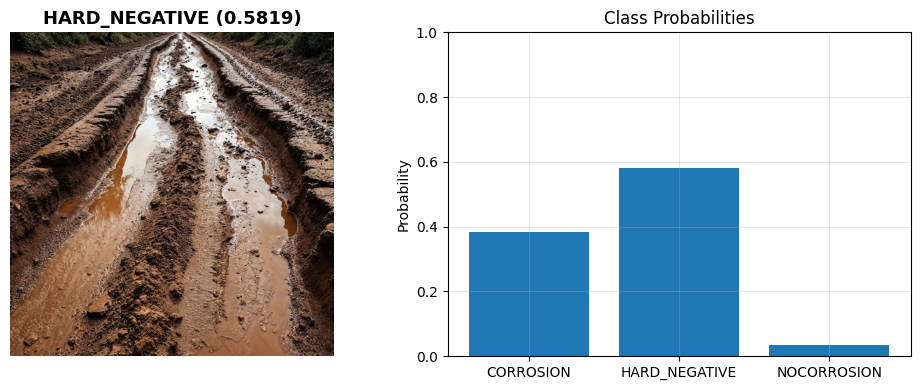

Single-image result:
image: testing6.jpg
model_choice: simclr
pred_index: 1
pred_class: HARD_NEGATIVE
confidence: 0.5819
probabilities: {'CORROSION': 0.3822, 'HARD_NEGATIVE': 0.5819, 'NOCORROSION': 0.0359}


In [32]:
result_single = predict_single_image_linear_probe(
    model_choice=MODEL_CHOICE,
    linear_probe_path=LINEAR_PROBE_PATH,
    image_path=SAMPLE_IMAGE_PATH,
    show=True
)

print("Single-image result:")
for k, v in result_single.items():
    print(f"{k}: {v}")


## Section 8 — Folder Sample Testing

In [33]:
def predict_folder_linear_probe(model_choice, linear_probe_path, folder_path, exts={".jpg", ".jpeg", ".png"}, max_images=None):
    folder_path = Path(folder_path)
    image_paths = sorted([p for p in folder_path.iterdir() if p.suffix.lower() in exts])

    if max_images is not None:
        image_paths = image_paths[:max_images]

    rows = []
    for image_path in image_paths:
        result = predict_single_image_linear_probe(
            model_choice=model_choice,
            linear_probe_path=linear_probe_path,
            image_path=image_path,
            show=False
        )
        rows.append(result)

    return rows

SAMPLE_FOLDER_PATH = "."

folder_results = predict_folder_linear_probe(
    model_choice=MODEL_CHOICE,
    linear_probe_path=LINEAR_PROBE_PATH,
    folder_path=SAMPLE_FOLDER_PATH,
    max_images=None
)

print(f"Total tested images: {len(folder_results)}")
for row in folder_results[:10]:
    print(f"{Path(row['image']).name:25s} -> {row['pred_class']:15s}  conf={row['confidence']:.4f}")


Total tested images: 6
testing1.jpg              -> HARD_NEGATIVE    conf=0.8471
testing2.jpg              -> NOCORROSION      conf=0.5156
testing3.jpg              -> CORROSION        conf=0.8852
testing4.jpg              -> HARD_NEGATIVE    conf=0.4109
testing5.jpg              -> HARD_NEGATIVE    conf=0.8696
testing6.jpg              -> HARD_NEGATIVE    conf=0.5819


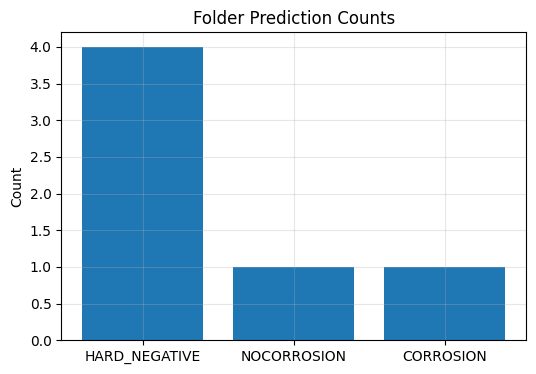

{'HARD_NEGATIVE': 4, 'NOCORROSION': 1, 'CORROSION': 1}

In [34]:
pred_counts = {}
for row in folder_results:
    pred_counts[row["pred_class"]] = pred_counts.get(row["pred_class"], 0) + 1

plt.figure(figsize=(6, 4))
plt.bar(list(pred_counts.keys()), list(pred_counts.values()))
plt.title("Folder Prediction Counts")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.show()

pred_counts


## Notes

This notebook is intentionally simpler than a full training notebook.

The key point is that it preserves the encoder-side feature handling from your earlier work:
- `simclr`: normalized `h`
- `supcon`: raw `h`
- `supcon_2stage`: normalized `h`

That matters, because changing that rule at inference time would make the linear probe inconsistent with the representation space you actually trained and evaluated.
